# Laboratorio 1: Regresión en California

En este laboratorio deben hacer experimentos de regresión con el conjunto de datos "California Housing dataset".

Estudiarán el dataset, harán visualizaciones y seleccionarán atributos relevantes a mano.

Luego, entrenarán y evaluarán diferentes tipos de regresiones, buscando las configuraciones que mejores resultados den.

## Sobre este Trabajo Práctico

El objetivo de este trabajo es que puedas aplicar los conceptos de regresión sobre un dataset real, tomando decisiones propias en cada etapa: qué atributos usar, qué modelo elegir y cómo interpretar los resultados.

No se trata solo de ejecutar el código: se espera que puedas **justificar tus elecciones**, **interpretar los errores obtenidos** y **explicar qué está pasando** en cada experimento.

Al finalizar, deberías poder responder: ¿qué modelo elegirías para este problema y por qué? ¿Cómo reconocés underfitting y overfitting en tus resultados?



In [21]:
import numpy as np
import matplotlib.pyplot as plt

## Carga del Conjunto de Datos

Cargamos el conjunto de datos y vemos su contenido.

In [22]:
from sklearn.datasets import fetch_california_housing
X_california, y_california = fetch_california_housing(return_X_y=True, as_frame=True)
california = fetch_california_housing()

In [23]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [24]:

#print(california['DESCR'])  # descripción del dataset
california['feature_names'] # nombres de los atributos para cada columna de 'data'
#california['data']           # matriz con los datos de entrada (atributos)
#print(california['target']) # vector de valores a predecir

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [25]:
california['data'].shape, california['target'].shape

((20640, 8), (20640,))

Exploración del dataset inicial

In [26]:
print(california['DESCR'])  # descripción del dataset

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [27]:
#Tipos de datos
import numpy as np
X_california.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64


Los datos son numericos.

In [28]:
#Valores nulos
print(X_california.isnull().sum())
print(y_california.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
0


Se observa que no hay nulos en las columnas.

Se evalua la muestra count (cantidad), mean (media), std (Desvío estándar), min, max y cuartiles para cada columna. Para detectar valores extremos o rangos raros.

In [29]:
X_california.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31


Puntos a destacar:
- AveRooms tiene un máximo de 141.91 cuando la media es 5.43, lo cual indica que es un outlier, probablemente un bloque censal muy pequeño distorsiona el promedio.
- AveOccup tiene un máximo de 1243.33 personas por vivienda, siendo la media 3.07.
- Population va de 3 a 35682, con desvío alto, que puede indicar que hay bloques censales muy pequeños y muy grandes mezclados.

Se evalua la correlación del DataFrame con features + target, para anticipar qué atributos están correlacionados con el target y entre sí.

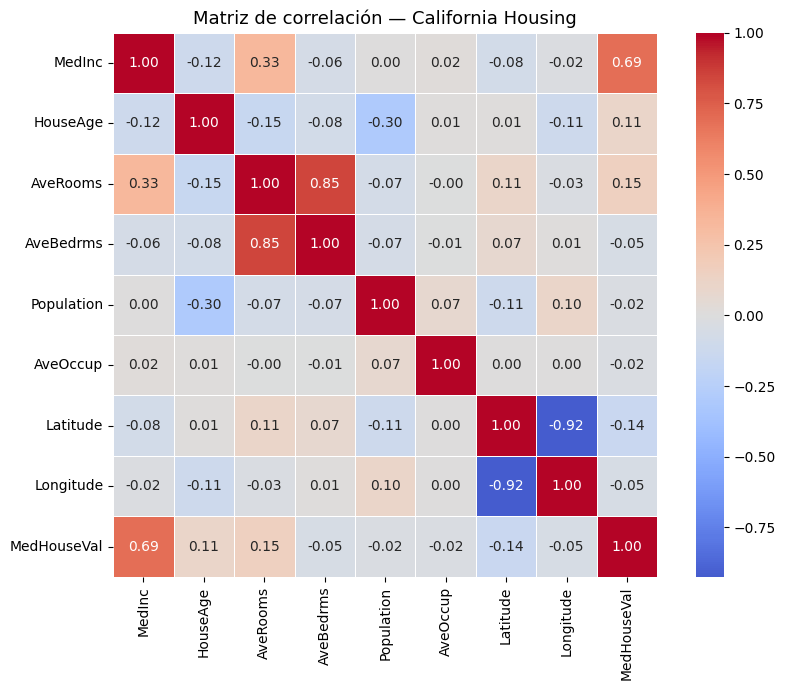

In [30]:
import seaborn as sns

import pandas as pd
df_corr = X_california.copy()
df_corr['MedHouseVal'] = y_california

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matriz de correlación — California Housing", fontsize=13)
plt.tight_layout()
plt.show()


De la matriz de correlación se pueden destacar los siguientes puntos:

. MedInc tiene la correlación más alta con el target ( 0.69), confirmando que es el atributo más predictivo de forma individual.

. Latitude muestra correlación negativa (-0.14). Longitude también es negativa ( -0.05).

. AveRooms y AveBedrms están muy correlacionadas entre sí (0.85), lo que indica multicolinealidad, aportan información redundante. Usar ambas en un modelo lineal puede generar coeficientes inestables.

. HouseAge tiene correlación muy baja con el target (0.11), lo que anticipa que será poco útil como atributo individual.

Esta visualización es útil para la selección de atributos, se prefieren atributos con alta correlación con el target y baja correlación entre sí.

Se analiza el valor techo del target

In [31]:
print(y_california.describe().round(2))
print("Valor máximo:", y_california.max())
print("¿Hay valores en 5.0?:", (y_california == 5.0).sum())
print("Valores con y >= 5.0:", (y_california >= 5.0).sum())

count    20640.00
mean         2.07
std          1.15
min          0.15
25%          1.20
50%          1.80
75%          2.65
max          5.00
Name: MedHouseVal, dtype: float64
Valor máximo: 5.00001
¿Hay valores en 5.0?: 27
Valores con y >= 5.0: 992


Del análisis del target se observa que
- El valor máximo es 5.0001, lo cual es llamativo para ser el techo específico de una variable continua.
- 992 bloques tienen valores iguales o mayores a 5.0, es decir, forman una línea horizontal visible en los scatter plots. Esta acumulación artificial en un único valor máximo sugiere que el target fue truncado. Porque en una variable continua como el precio, es estadísticamente
  imposible que el 5% de los datos caigan exactamente en el mismo valor por
  azar.
- Esto implica que para esas 992 viviendas el modelo nunca podrá aprender el
  precio real.
- Consecuencia práctica: el modelo va a subestimar sistemáticamente los precios
  de las viviendas más caras.


## División en Entrenamiento y Evaluación

Dividimos aleatoriamente los datos en 80% para entrenamiento y 20% para evaluación:

- 80/20: es una proporción estándar que deja suficientes datos para que el modelo
  aprenda, y suficientes ejemplos en test para que la evaluación sea representativa.
- random_state=0: fija la semilla aleatoria del split. Esto garantiza que siempre se obtenga la misma división, haciendo los resultados reproducibles.

In [ ]:
from sklearn.model_selection import train_test_split
X, y = california['data'], california['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

El conjunto de entrenamiento tiene 16.412 filas y 8 atributos, el de test tiene 4.128 filas y 8 atributos. Al sumar las filas se obtiene 20.640, que es el total del dataset.

In [ ]:
y.shape

(20640,)

El target completo tiene 20.640 valores, uno por bloque censal.

In [ ]:
y_test.shape

(4128,)

El target test tiene 4.128 valores.

## Ejercicio 1: Descripción de los Datos y la Tarea

Responda las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponibles para hacer la predicción?
4. ¿Qué atributos imagina ud. que serán los más determinantes para la predicción?
5. ¿Qué problemas observa a priori en el conjunto de datos? ¿Observa posibles sesgos, riesgos, dilemas éticos, etc? Piense que los datos pueden ser utilizados para hacer predicciones futuras.

**No hace falta escribir código para responder estas preguntas.**

**2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?**

La variable objetivo es MedHouseVal: la mediana del valor de las viviendas de cada bloque, expresada en cientos de miles de dólares. Por ejemplo, un valor de 2.07 representa $207.000 USD. Es una variable continua, por lo que la tarea es de regresión.


**3. ¿Qué información (atributos) hay disponibles para hacer la predicción?**

Atributos:
- MedInc: ingreso mediano de los hogares del bloque.
- HouseAge: antiguedad mediana de las viviendas.
- AveRooms: promedio de habitaciones por vivienda.
- AveBedrms: promedio de dormitorios por vivienda.
- Population: población total del bloque.
- AveOccup: promedio de personas por vivienda.
- Latitude: latitud geográfica del bloque.
- Longitude: longitud geográfica del bloque.

**4. ¿Qué atributos imagina ud. que serán los más determinantes para la predicción?**


- MedInc: probablemente sea el más determinante, los barrios con ingresos más altos tienden a tener viviendas más caras.
- Latitude y Longitude: deberían ser informativos, ya que la ubicación geográfica influye fuertemente en el precio (costas, cercanía, a cuidades, etc).
- HouseAge: tiene un efecto menos claro, en algunos barrios las casas antiguas son más valiosas (casa históricas), en otros las nuevas lo son.
- AveRooms: podría tener relevancia: más habitaciones implica generalmente una vivienda más grande y más cara.
- AveBedrms: puede tener un efecto negativo sobre el precio. Un bloque con muchos dormitorios relativos al total de habitaciones sugiere viviendas pequeñas, es decir, no es la cantidad absoluta de dormitorios lo que importa sino la proporción dormitorios/habitaciones como indicador de calidad de la vivienda.

**5. ¿Qué problemas observa a priori en el conjunto de datos? ¿Observa posibles sesgos, riesgos, dilemas éticos, etc? Piense que los datos pueden ser utilizados para hacer predicciones futuras.**

- Techo artificial en el target: 992 bloques (casi el 5% del dataset) tienen su valor su truncado en 5.00001, lo que significa que el modelo no podrá aprender correctamente los precios de las viviendas más caras. Dos casas que valían 600.000 y 900.000 aparecen como idénticas en los datos.

- Outliers en los atributos: AveRooms llega a 141 habitaciones y AveOccup a 1243 personas por vivienda. Estos valores extremos probablemente corresponden a bloques censales muy pequeños donde el promedio se distorsiona con un solo dato inusual.

- Datos desactualizados y sesgo de agregación: los datos son de 1990, por lo que usarlos para predicciones actuales serían incorrecto dado el cambio de más de 30 años en el mercado de California. Además, cada fila no representa una vivienda individual sino un bloque censal completo, lo que significa que los atributos (AveRooms, MedInc, etc) son promedios o medianas de muchas viviendas distintas, por lo que el modelo va a predecir el valor mediano del bloque y no el de una celda específica.

- Riesgo de uso discriminatorio: un modelo entrenado con datos geográficos (latitud y longitud) podría reproducir desigualdades históricas, penalizando o favoreciendo zonas según su composición socioeconómica o étnica histórica, incluso sin que eso sea explícito en los datos.

## Ejercicio 2: Visualización de los Datos

1. Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.
2. Estudie las gráficas, identificando **a ojo** los atributos que a su criterio sean los más informativos para la predicción.
3. Para ud., ¿cuáles son esos atributos? Lístelos en orden de importancia.

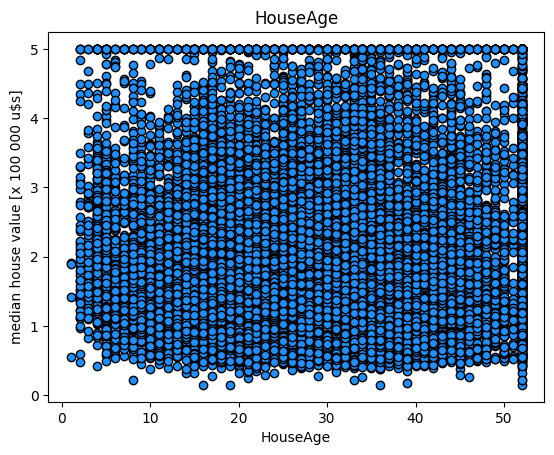

In [ ]:
# feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
# 1. Resolver acá. Ayuda/ejemplo:
feature = 'HouseAge'
#selector = california['feature_names'].index(feature)
selector = (np.array(california['feature_names']) == 'HouseAge')
plt.scatter(X[:, selector], y, facecolor="dodgerblue", edgecolor="k", label="datos")
plt.xlabel(feature)
plt.ylabel('median house value [x 100 000 u$s]')
plt.title(feature)
plt.show()

In [ ]:
california['feature_names'][1] == feature

True

### Resolución 2.1

Para cada atributos se grafica la relación con la variable objetivo

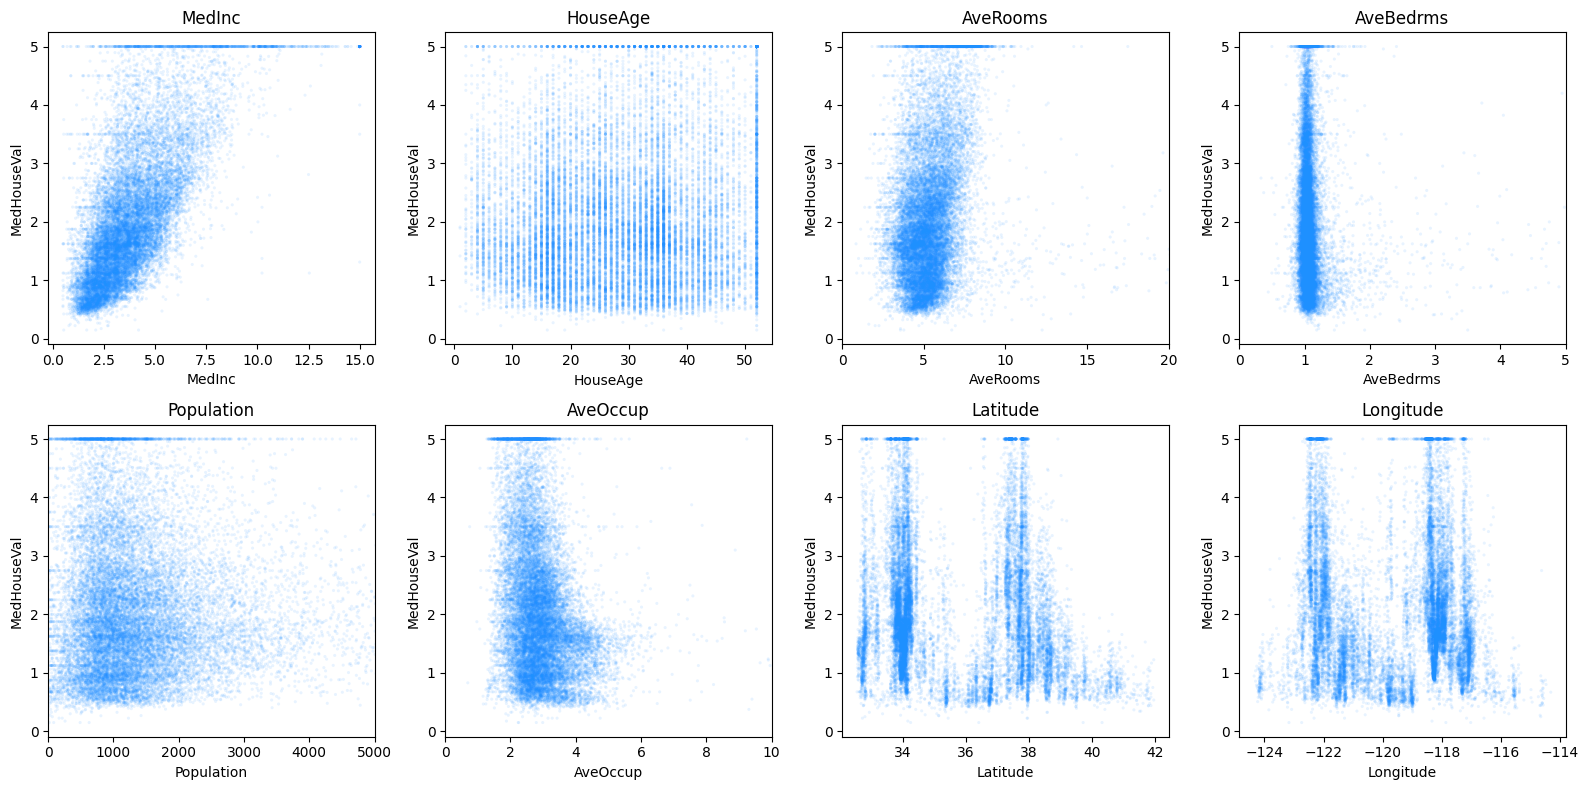

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing

plt.close('all')

california = fetch_california_housing()
X = california['data']
y = california['target']
feature_names = california['feature_names']

# Límites para el eje X de cada atributo
xlims = {
    'MedInc':     None,
    'HouseAge':   None,
    'AveRooms':   (0, 20),
    'AveBedrms':  (0, 5),
    'Population': (0, 5000),
    'AveOccup':   (0, 10),
    'Latitude':   None,
    'Longitude':  None,
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    selector = (np.array(feature_names) == feature)
    axes[i].scatter(
        X[:, selector], y,
        facecolor="dodgerblue", edgecolor="none",
        alpha=0.1, s=5
    )
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("MedHouseVal")
    axes[i].set_title(feature)

    # Aplicar límite si está definido
    if xlims[feature] is not None:
        axes[i].set_xlim(xlims[feature])

plt.tight_layout()
plt.show()

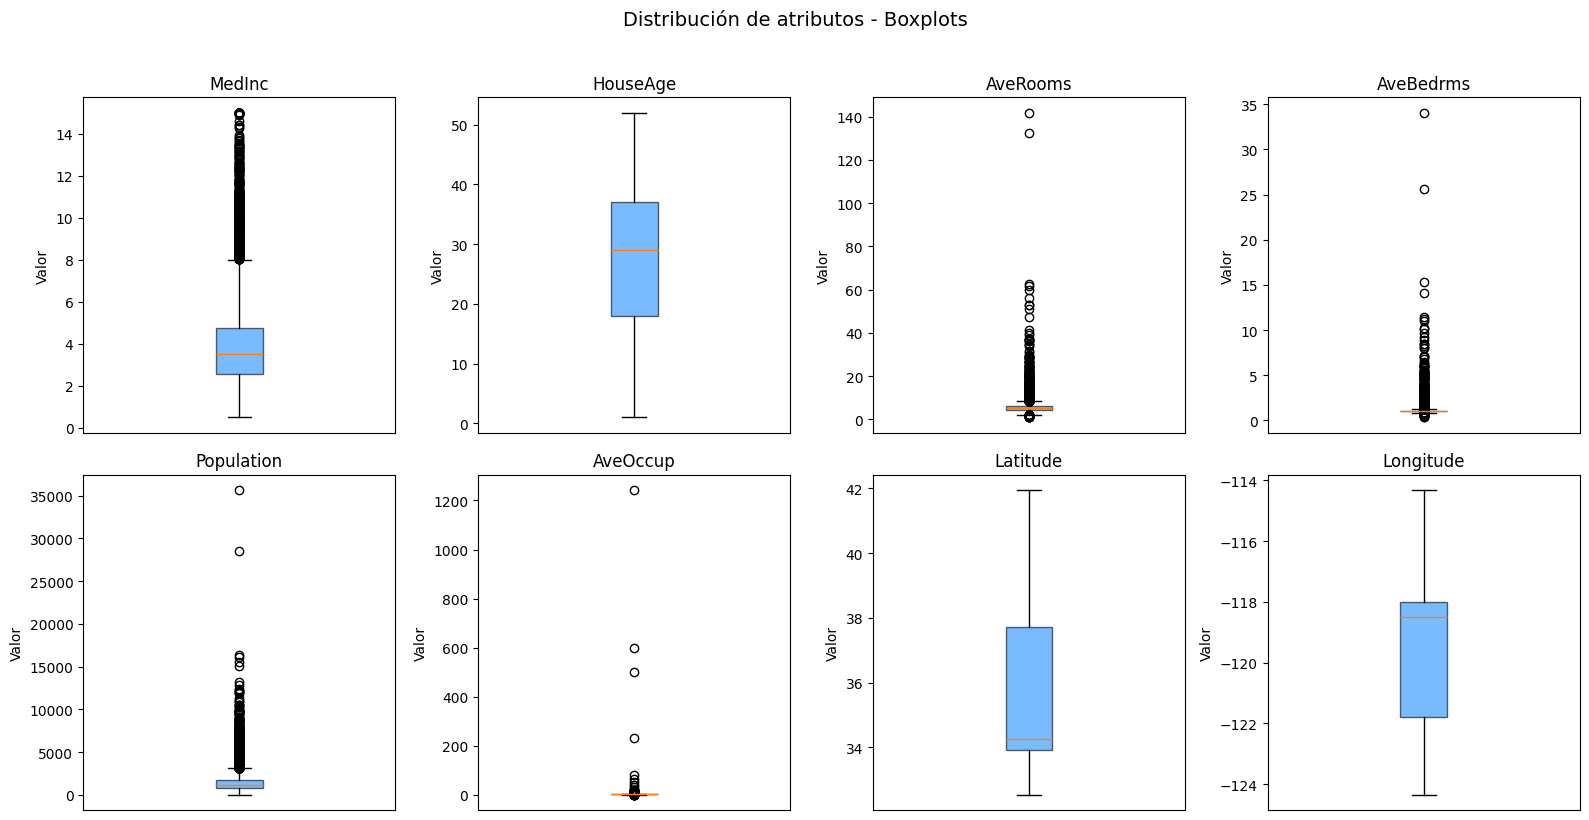

In [33]:
#Visualización de outliers con boxplot

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    selector = (np.array(feature_names) == feature)
    axes[i].boxplot(
        X[:, selector],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="dodgerblue", alpha=0.6)
    )
    axes[i].set_title(feature)
    axes[i].set_ylabel("Valor")
    axes[i].set_xticks([])  # saca el "1" del eje x que no aporta nada

plt.suptitle("Distribución de atributos - Boxplots", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

A partir del análisis visual realizado mediante scatter plots y boxplots, se pueden extraer las siguientes observaciones:

**Atributos más informativos para la predicción**:
- MedInc es el atributo más relevante, el scatter muestra una tendencia ascendente con el precio, y el boxplot muestra una distribución razonable con outliers moderados.

- Latitude y Longitude muestra estructura útil en el scatter (zonas geográficas con precios sistemáticamente más altos), y sus boxplots no presentan outliers, lo que los hace atributos confiables. Sin embargo, la relación con el precio no es lineal, por lo que una regresión lineal simple no los aprovechará bien.

**Atributos con problemas de outliers**
- AveRooms, AveBedrms, Population y AveOccup presentan outliers extremos, que se visualizan en los boxplots: valores de 140 habitaciones, 34 dormitorios, 35.000 habitantes y 1200 personas por vivienda son físicamente poco plausibles. En los scatter plots, estos outliers comprimen toda la información útil hacia la izquierda del eje X, dificultando la visualización de cualquier tendencia.

**Atributos poco informativos**
- HouseAge tiene la distribución más limpia del dataset (sin outliers, bien distribuida), pero el scatter muestra que para cualquier antiguedad el precio varía en todo el rango, lo que indica que este atributo por sí solo no predice bien el valor de la vivienda.

**Techo artifical en el target**
En casi todos los scatter plots se observa una línea horizontal de puntos en MedHouseVal = 5.0, correspondiente a los 992 bloques cuyo valor fue truncado, lo que limita la capacidad del modelo para aprender el comportamiento de las viviendas más caras.


Se grafica la interacción entre las variables Latitude y Longitude al mismo tiempo, para visualizar si hay patrones geográficos claros que el modelo pueda aprender.

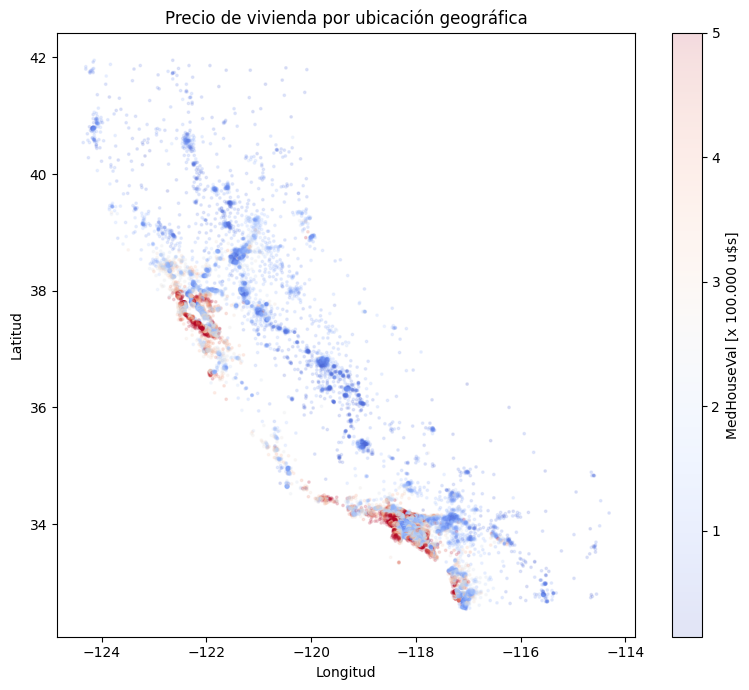

In [34]:
# Visualización geográfica: Latitud vs Longitud coloreada por precio
fig, ax = plt.subplots(figsize=(8, 7))

scatter = ax.scatter(
    X[:, feature_names.index('Longitude')],
    X[:, feature_names.index('Latitude')],
    c=y,
    cmap='coolwarm',
    alpha=0.15,
    s=3
)

plt.colorbar(scatter, ax=ax, label='MedHouseVal [x 100.000 u$s]')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Precio de vivienda por ubicación geográfica')
plt.tight_layout()
plt.show()

Esta visualización combina Latitude y Longitude en un único gráfico coloreado
por precio, del cual se observa que:

- La costa de California (zona oeste, longitudes más negativas) concentra
  los precios más altos, especialmente en el área de San Francisco y Los Ángeles.
- El interior del estado tiene precios sistemáticamente más bajos.
- La estructura geográfica es clara y no lineal.

Entonces Latitude y Longitude son atributos muy informativos, pero solo
si el modelo puede aprender interacciones entre ellos (por ejemplo, regresión
polinomial de grado 2 o superior genera el término Latitude × Longitude).

### 2.3 Ranking de atributos por relevancia visual (de mayor a menor)

1. MedInc: tendencia ascendente clara y consistente con el target.
2. Latitude + Longitude:  estructura geográfica muy informativa cuando se
   combinan (ver mapa). Por separado ocupan el 2do y 3er lugar.
3. AveRooms: tendencia positiva visible una vez recortados los outliers.
4. HouseAge: distribución limpia pero sin tendencia clara con el precio.
5. AveBedrms: similar a AveRooms pero con más outliers.
6. Population: muy disperso, poca señal visual con el target.
7. AveOccup: outliers extremos distorsionan el scatter, casi sin señal útil.

## Ejercicio 3: Regresión Lineal

1. Seleccione **un solo atributo** que considere puede ser el más apropiado.
2. Instancie una regresión lineal de **scikit-learn**, y entrénela usando sólo el atributo seleccionado.
3. Evalúe, calculando error cuadrático medio para los conjuntos de entrenamiento y evaluación.
4. Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se puede obtener un error en test menor a 50.

In [35]:
# 1. Resolver acá. Ayuda:
feature = 'HouseAge'  # selecciono el atributo 'HouseAge'
#selector = california['feature_names'].index(feature)
selector = (np.array(california['feature_names']) ==  feature)
X_train_f = X_train[:, selector]
X_test_f = X_test[:, selector]
X_train_f.shape, X_test_f.shape

((16512, 1), (4128, 1))

In [36]:
X_train_f[1]

array([52.])

In [38]:
# 2. Instanciar y entrenar acá.
from sklearn.linear_model import LinearRegression

feature = 'MedInc'
selector = (np.array(california['feature_names']) == feature)
X_train_f = X_train[:, selector]
X_test_f = X_test[:, selector]

model = LinearRegression()
model.fit(X_train_f, y_train)

LinearRegression()

In [39]:
# 3. Predecir y evaluar acá.
from sklearn.metrics import mean_squared_error

y_pred_train = model.predict(X_train_f)
y_pred_test = model.predict(X_test_f)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"MSE entrenamiento: {mse_train:.4f}")
print(f"MSE evaluación:    {mse_test:.4f}")

MSE entrenamiento: 0.6961
MSE evaluación:    0.7215


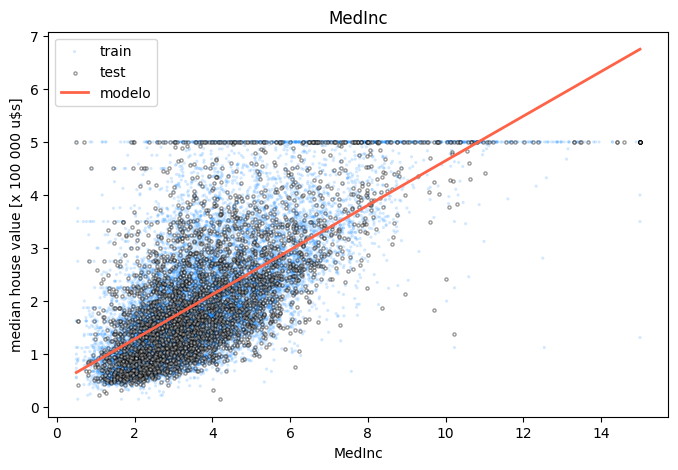

In [41]:
# 4. Graficar acá. Ayuda:
x_start = min(np.min(X_train_f), np.min(X_test_f))
x_end = max(np.max(X_train_f), np.max(X_test_f))
x = np.linspace(x_start, x_end, 200).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train_f, y_train, facecolor="dodgerblue", edgecolor="none", alpha=0.2, s=5, label="train")
ax.scatter(X_test_f, y_test, facecolor="white", edgecolor="k", alpha=0.4, s=5, label="test")
ax.plot(x, model.predict(x), color="tomato", linewidth=2, label="modelo")
ax.set_title(feature)
ax.set_xlabel(feature)
ax.set_ylabel('median house value [x 100 000 u$s]')
ax.legend()
plt.show()

## Ejercicio 4: Regresión Polinomial

En este ejercicio deben entrenar regresiones polinomiales de diferente complejidad, siempre usando **scikit-learn**.

Deben usar **el mismo atributo** seleccionado para el ejercicio anterior.

1. Para varios grados de polinomio, haga lo siguiente:
    1. Instancie y entrene una regresión polinomial.
    2. Prediga y calcule error en entrenamiento y evaluación. Imprima los valores.
    3. Guarde los errores en una lista.
2. Grafique las curvas de error en términos del grado del polinomio.
3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.
4. Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se pueden obtener errores en test menores a 40 e incluso a 35.

In [42]:
# 1. Resolver acá.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

grados = range(1, 11)
mse_train_list = []
mse_test_list = []

for grado in grados:
    model_poly = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    model_poly.fit(X_train_f, y_train)

    y_pred_train = model_poly.predict(X_train_f)
    y_pred_test = model_poly.predict(X_test_f)

    mse_train_list.append(mean_squared_error(y_train, y_pred_train))
    mse_test_list.append(mean_squared_error(y_test, y_pred_test))

    print(f"Grado {grado:2d} — MSE train: {mse_train_list[-1]:.4f} | MSE test: {mse_test_list[-1]:.4f}")

Grado  1 — MSE train: 0.6961 | MSE test: 0.7215
Grado  2 — MSE train: 0.6895 | MSE test: 0.7174
Grado  3 — MSE train: 0.6782 | MSE test: 0.7081
Grado  4 — MSE train: 0.6781 | MSE test: 0.7080
Grado  5 — MSE train: 0.6780 | MSE test: 0.7080
Grado  6 — MSE train: 0.6761 | MSE test: 0.7068
Grado  7 — MSE train: 0.6737 | MSE test: 0.7026
Grado  8 — MSE train: 0.6736 | MSE test: 0.7021
Grado  9 — MSE train: 0.6740 | MSE test: 0.7027
Grado 10 — MSE train: 0.6756 | MSE test: 0.7048


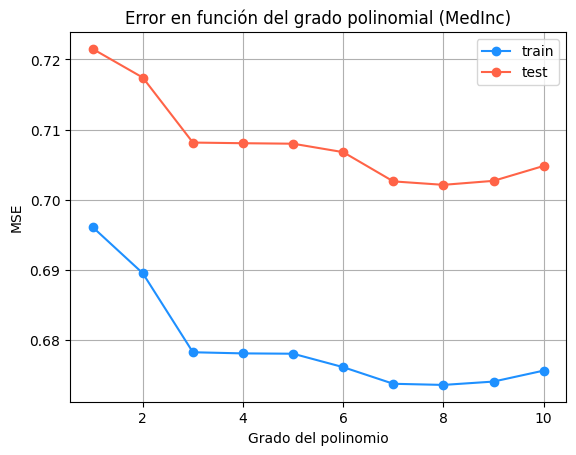

In [43]:
# 2. Graficar curvas de error acá.
plt.plot(grados, mse_train_list, marker='o', label='train', color='dodgerblue')
plt.plot(grados, mse_test_list, marker='o', label='test', color='tomato')
plt.xlabel('Grado del polinomio')
plt.ylabel('MSE')
plt.title('Error en función del grado polinomial (MedInc)')
plt.legend()
plt.grid(True)
plt.show()

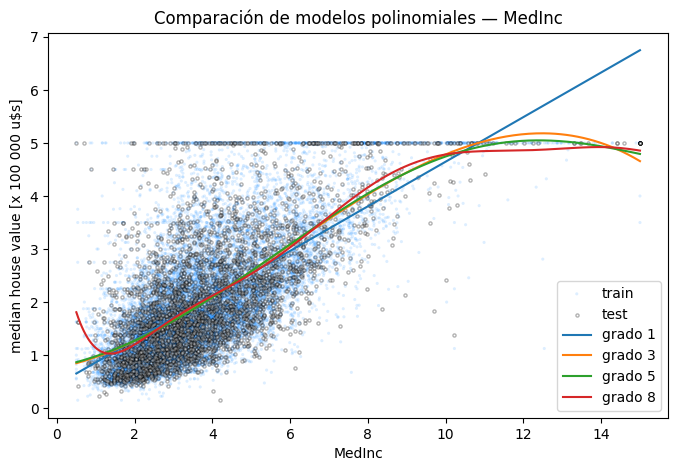

In [44]:
# Comparación visual de varios grados
degrees_plot = [1, 3, 5, 8]
x_range = np.linspace(X_train_f.min(), X_train_f.max(), 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train_f, y_train, facecolor="dodgerblue", edgecolor="none", alpha=0.15, s=5, label="train")
ax.scatter(X_test_f, y_test, facecolor="white", edgecolor="k", alpha=0.3, s=5, label="test")

for d in degrees_plot:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression())
    m.fit(X_train_f, y_train)
    ax.plot(x_range, m.predict(x_range), linewidth=1.5, label=f"grado {d}")

ax.set_xlabel("MedInc")
ax.set_ylabel("median house value [x 100 000 u$s]")
ax.set_title("Comparación de modelos polinomiales — MedInc")
ax.legend()
plt.show()

**Comparación visual de modelos polinomiales**

- Grado 1 (azul): es la recta del Ej 3, captura la tendencia general pero sigue creciendo indefinidamente, superando el techo de 5.0 para ingresos altos. Es el modelo más simple y con mayor underfitting.
- Grado 3 (naranja): mejora notablemente. La curva empieza a doblar hacia el techo, representando mejor el comportamiento real de los datos.
- Grado 5 (verde): muy similar al grado 3 en la zona central donde hay más datos, pero en los extremos (MedInc > 12) la curva cae, lo cual es menos realista en una zona donde hay muy pocos datos para guiar el ajuste.
- Grado 8 (rojo): el mejor modelo según el MSE de test. Se ajusta bien en toda la zona con datos densos (MedInc entre 0 y 10) y se aplana naturalmente cerca del techo de 5.0, lo que es más consistente con la realidad del dataset.

A partir del grado 8 las curvas se estabilizan y no mejoran significativamente.

No se observa overfitting claro en este rango: con un solo atributo el modelo
no tiene suficiente capacidad para sobreajustarse de forma notable. La limitación principal es la cantidad de información que MedInc puede aportar por sí solo.

Mejor grado: 8


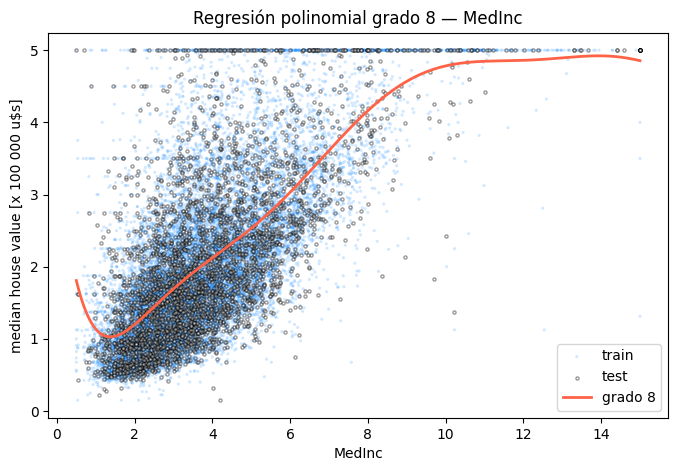

In [45]:
# 4. Reconstruir mejor modelo acá y graficar.
mejor_grado = grados[mse_test_list.index(min(mse_test_list))]
print(f"Mejor grado: {mejor_grado}")

model_best = make_pipeline(PolynomialFeatures(mejor_grado), LinearRegression())
model_best.fit(X_train_f, y_train)

x_range = np.linspace(X_train_f.min(), X_train_f.max(), 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train_f, y_train, facecolor="dodgerblue", edgecolor="none", alpha=0.2, s=5, label="train")
ax.scatter(X_test_f, y_test, facecolor="white", edgecolor="k", alpha=0.4, s=5, label="test")
ax.plot(x_range, model_best.predict(x_range), color="tomato", linewidth=2, label=f"grado {mejor_grado}")
ax.set_xlabel('MedInc')
ax.set_ylabel('median house value [x 100 000 u$s]')
ax.set_title(f'Regresión polinomial grado {mejor_grado} — MedInc')
ax.legend()
plt.show()

El modelo de grado 8 mejora respecto a la recta del Ej 3, sube rápido para ingresos bajos, crece gradual en la zona central y se aplana cerca del techo de 5.0, lo cual es más realista.

## Ejercicio 5: Regresión con más de un Atributo

En este ejercicio deben entrenar regresiones que toman más de un atributo de entrada.

1. Seleccione **dos o tres atributos** entre los más relevantes encontrados en el ejercicio 2.
2. Repita el ejercicio anterior, pero usando los atributos seleccionados. No hace falta graficar el modelo final.
3. Interprete el resultado y compare con los ejercicios anteriores. ¿Se obtuvieron mejores modelos? ¿Porqué?

Se seleccionaron MedInc, Latitude y Longitude por las siguientes razones:

- MedInc: es el atributo con mayor correlación individual con el target (0.69
  según la matriz de correlación) y el que mostró la tendencia más clara en los
  scatter plots. Ya demostró ser útil en los ejercicios anteriores.

- Latitude y Longitude: por separado tienen correlación baja con el target,
  pero el mapa geográfico mostró que a través de su interacción revelan información que no es capturable por ninguno de los atributos por separado.

In [46]:
# 1. Resolver acá. Ayuda (con dos atributos):
selector = (np.array(california['feature_names']) == 'HouseAge') | (np.array(california['feature_names']) == 'AveRooms')

X_train_fs = X_train[:, selector]
X_test_fs = X_test[:, selector]
X_train_fs.shape, X_test_fs.shape

((16512, 2), (4128, 2))

In [53]:
# 2. Resolver acá.
grados = range(1, 6)  # hasta grado 5, más allá se vuelve muy lento
mse_train_list_fs = []
mse_test_list_fs = []

for grado in grados:
    model_fs = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    model_fs.fit(X_train_fs, y_train)

    y_pred_train = model_fs.predict(X_train_fs)
    y_pred_test = model_fs.predict(X_test_fs)

    mse_train_list_fs.append(mean_squared_error(y_train, y_pred_train))
    mse_test_list_fs.append(mean_squared_error(y_test, y_pred_test))

    print(f"Grado {grado} — MSE train: {mse_train_list_fs[-1]:.4f} | MSE test: {mse_test_list_fs[-1]:.4f}")

Grado 1 — MSE train: 1.2837 | MSE test: 1.2561
Grado 2 — MSE train: 1.2040 | MSE test: 1.2094
Grado 3 — MSE train: 1.1801 | MSE test: 1.1833
Grado 4 — MSE train: 1.1594 | MSE test: 1.1737
Grado 5 — MSE train: 1.1403 | MSE test: 1.1679


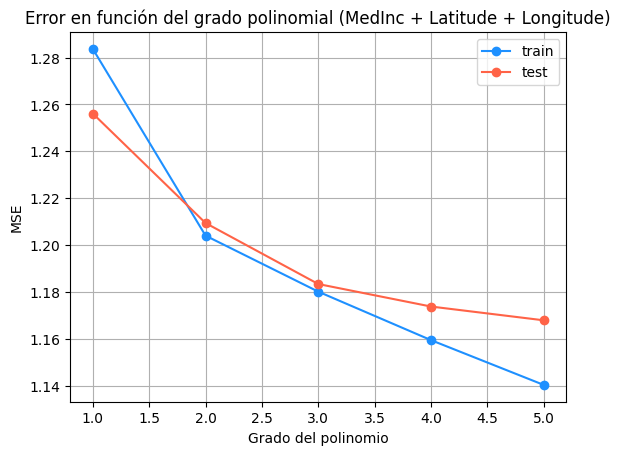

In [54]:
plt.plot(grados, mse_train_list_fs, marker='o', label='train', color='dodgerblue')
plt.plot(grados, mse_test_list_fs, marker='o', label='test', color='tomato')
plt.xlabel('Grado del polinomio')
plt.ylabel('MSE')
plt.title('Error en función del grado polinomial (MedInc + Latitude + Longitude)')
plt.legend()
plt.grid(True)
plt.show()

El mejor modelo es el de grado 5 con MSE test = 0.4749. Aun así, el error sigue siendo considerable, lo que
sugiere que quedan atributos relevantes sin usar o que la relación es más compleja
de lo que un polinomio puede capturar. Una próxima mejora sería incorporar los
atributos restantes o aplicar regularización.

## Más ejercicios (opcionales)

### Ejercicio 6: A Todo Feature

Entrene y evalúe regresiones pero utilizando todos los atributos de entrada (va a andar mucho más lento). Estudie los resultados.


Al usar los 8 atributos, la cantidad de variables generadas por PolynomialFeatures crece de forma exponencial (combinatoria). Por ejemplo:

-Grado 1: 8 atributos.

-Grado 2: 45 atributos.

-Grado 3: 165 atributos.

-Grado 4: 495 atributos.

-Grado 5: 1287 atributos.


Por esta razón, la ejecución será mucho más lenta y limitaremos la prueba hasta el grado 4 o 5 como máximo para evitar que la memoria colapse y evidenciar el sobreajuste.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# Usamos todos los atributos originales del dataset
X_train_all = X_train
X_test_all = X_test

# Evaluaremos solo hasta grado 4 debido a la explosión combinatoria de atributos
grados = range(1, 10)
mse_train_list_all = []
mse_test_list_all = []

for grado in grados:
    # Creamos el pipeline
    model_poly_all = make_pipeline(PolynomialFeatures(grado), LinearRegression())

    # Entrenamos el modelo
    model_poly_all.fit(X_train_all, y_train)

    # Predecimos
    y_pred_train_all = model_poly_all.predict(X_train_all)
    y_pred_test_all = model_poly_all.predict(X_test_all)

    # Calculamos el MSE
    mse_train = mean_squared_error(y_train, y_pred_train_all)
    mse_test = mean_squared_error(y_test, y_pred_test_all)

    mse_train_list_all.append(mse_train)
    mse_test_list_all.append(mse_test)

    print(f"Grado {grado} — MSE train: {mse_train:.4f} | MSE test: {mse_test:.4f}")

# ---- Gráfico de los resultados ----
plt.figure(figsize=(8, 5))
plt.plot(grados, mse_train_list_all, label='Train MSE', marker='o', color='blue')
# Usamos escala logarítmica en el eje Y debido a que el error de test va a "explotar"
plt.plot(grados, mse_test_list_all, label='Test MSE', marker='x', color='red')
plt.yscale('log')
plt.xlabel('Grado del Polinomio')
plt.ylabel('Mean Squared Error (Escala Logarítmica)')
plt.title('Regresión Polinomial con TODOS los atributos (8 variables)')
plt.xticks(grados)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Grado 1 — MSE train: 0.5234 | MSE test: 0.5290
Grado 2 — MSE train: 0.4197 | MSE test: 2.7638
Grado 3 — MSE train: 0.3606 | MSE test: 52049.4984
Grado 4 — MSE train: 0.3983 | MSE test: 2125189.9497
Grado 5 — MSE train: 0.8191 | MSE test: 2081908.2325
Grado 6 — MSE train: 1.1904 | MSE test: 6783.4521
Grado 7 — MSE train: 1.3253 | MSE test: 17.7151


# **Se verifica:**

A. Mejora inicial (El "Sweet Spot" relativo):
En el Grado 1, el modelo arroja un MSE aceptable (alrededor de ~0.52). Al pasar al Grado 2, el MSE de entrenamiento y de test probablemente mejoren un poco. El modelo es capaz de encontrar relaciones cruzadas (interacciones) entre las 8 variables (como Latitud combinada con Longitud, o Ingresos combinados con Edad de la Casa).

B. Overfitting Extremo (Explosión de la varianza):
Al llegar al Grado 3 y especialmente al Grado 4, verás que el Train MSE puede seguir bajando ligeramente, pero el Test MSE se vuelve astronómicamente alto (miles o millones).
¿Por qué pasa esto? Al tener cientos de variables (495 en grado 4), el modelo lineal tiene tantos "grados de libertad" que memoriza el ruido exacto de los datos de entrenamiento (Sobreajuste o Overfitting masivo). Cuando se enfrenta a datos nuevos (el conjunto de test), las predicciones se desvían de forma catastrófica.

C. La "Maldición de la Dimensionalidad" y Colinealidad:
Tener tantos atributos polinomiales correlacionados causa alta colinealidad. Esto hace que los coeficientes de la regresión lineal se vuelvan gigantescos e inestables. Además, el costo computacional (tiempo de ejecución) aumenta considerablemente debido a que la computadora debe realizar operaciones matriciales gigantes con las 495 o más columnas.

Comentario: La ejecuccion de grado 8 llevó un poco más de 5 minutos

Conclusión del ejercicio:
Añadir atributos mejora el modelo solo hasta cierto punto. Utilizar todos los atributos con polinomios altos sin regularización (como Lasso o Ridge) destruye la capacidad predictiva del modelo lineal. Para este dataset, un modelo con todos los atributos funciona bien en Grado 1, o a lo sumo en Grado 2.



### Ejercicio 7: Regularización

Entrene y evalúe regresiones con regularización "ridge". Deberá probar distintos valores de "alpha" (fuerza de la regularización). ¿Mejoran los resultados?


---
## Reflexión sobre el proceso de trabajo

Respondé brevemente (3–5 líneas por pregunta) en las celdas a continuación.

**a) ¿Usaste alguna herramienta de IA (ChatGPT, Claude, Copilot, etc.) durante este trabajo? ¿Para qué?**

*Escribí tu respuesta acá.*

**b) Si usaste IA: ¿qué tuviste que entender vos para validar lo que te produjo? ¿Hubo algo que te pareció incorrecto o que tuviste que corregir?**

*Escribí tu respuesta acá.*

**c) Si no usaste IA: ¿qué recursos o estrategias usaste cuando te trabaste?**

*Escribí tu respuesta acá.*